In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
import seaborn as sns


In [3]:
df = pd.read_csv('../dataset/ghi_temp.csv')

In [4]:
df.head()


,Year,Month,Day,Hour,Minute,GHI,Temperature,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2019,1,1,0,0,0,16.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,1,1,1,0,0,16.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,1,1,2,0,0,16.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,1,3,0,0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,1,1,4,0,0,15.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
ghi_col = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'Temperature']
df = df[ghi_col]
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature
0,2019,1,1,0,0,0,16.3
1,2019,1,1,1,0,0,16.2
2,2019,1,1,2,0,0,16.1
3,2019,1,1,3,0,0,16.0
4,2019,1,1,4,0,0,15.9


In [6]:
df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

In [7]:
df = df[['datetime', 'GHI', 'Temperature']]

df.set_index('datetime', inplace=True)

df.head()

,GHI,Temperature
datetime,,
2019-01-01 00:00:00,0,16.3
2019-01-01 01:00:00,0,16.2
2019-01-01 02:00:00,0,16.1
2019-01-01 03:00:00,0,16.0
2019-01-01 04:00:00,0,15.9


<Axes: xlabel='datetime'>

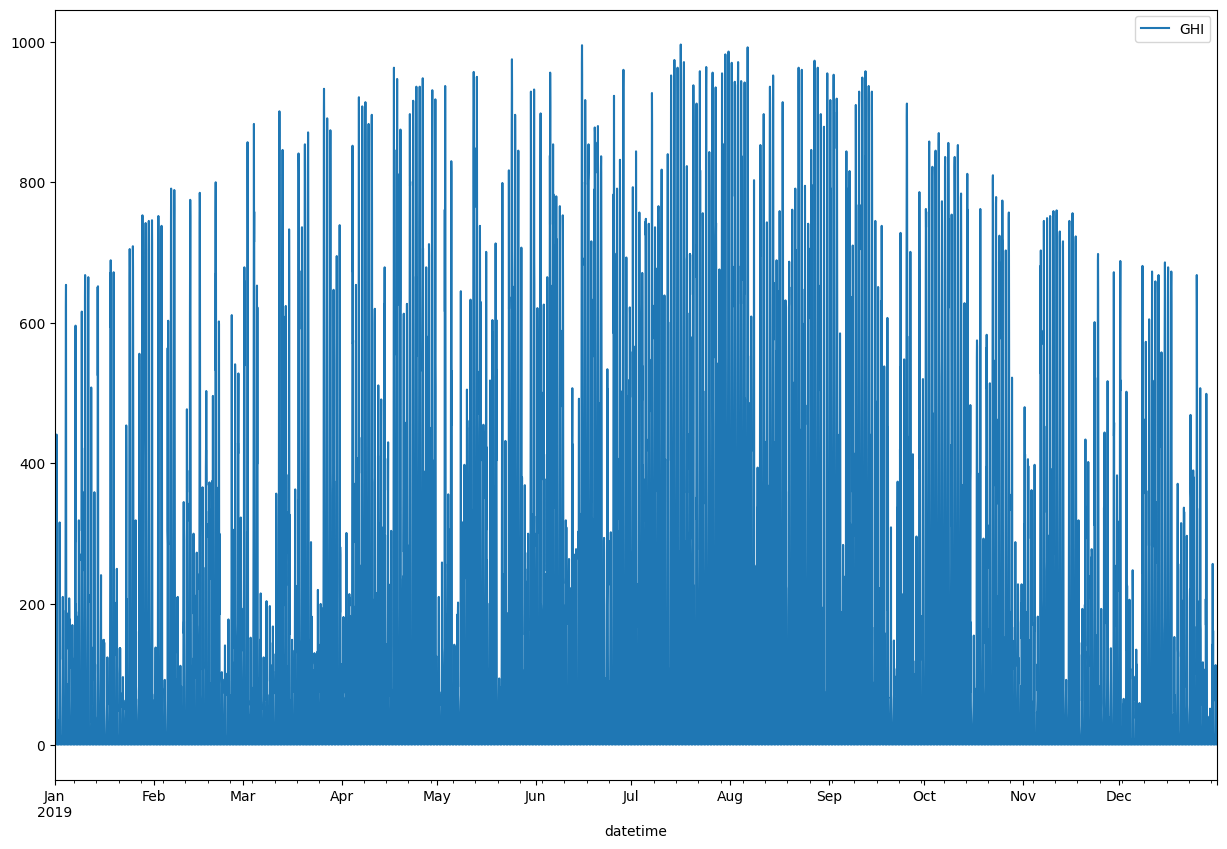

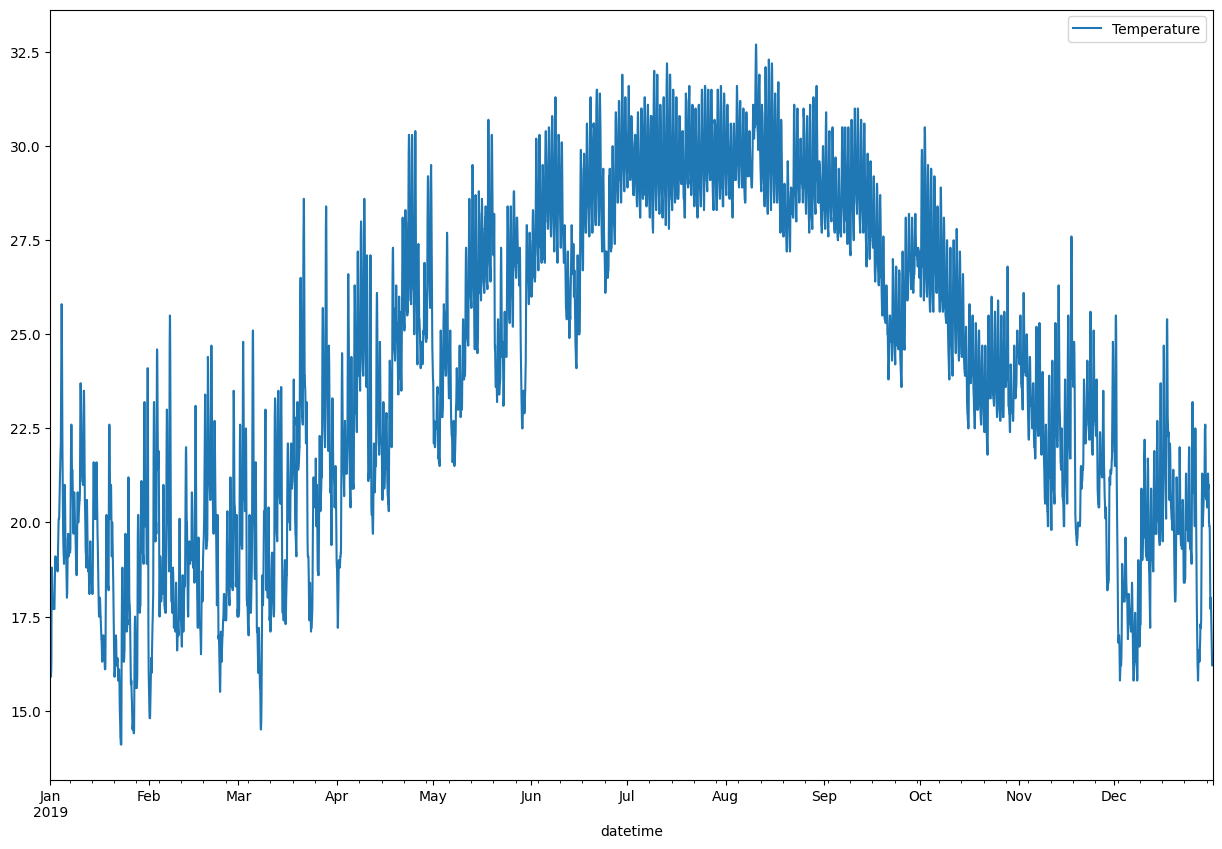

In [8]:
df.plot(y='GHI', figsize=(15,10))
df.plot(y='Temperature', figsize=(15,10))

In [9]:
print(df.columns)

Index(['GHI', 'Temperature'], dtype='object')


In [10]:
print(df.shape)

(8760, 2)


In [11]:
target = df['GHI'].to_numpy()

x, x_test, y, y_test = train_test_split(df, target, test_size=0.1, shuffle=False)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.15, shuffle=False)

print(x_train.shape, x_val.shape, x_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(6701, 2) (1183, 2) (876, 2)
(6701,) (1183,) (876,)


In [17]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

preprocessing= ColumnTransformer([
    ('pipe',make_pipeline(StandardScaler()), list(df.columns))
    ])

x_train_scaled = preprocessing.fit_transform(x_train) 
x_val_scaled = preprocessing.transform(x_val) 
x_test_scaled = preprocessing.transform(x_test) 

In [21]:
window_len = 24
batch_size = 1
train_gen = TimeseriesGenerator(data=x_train_scaled, targets=y_train, length=window_len, shuffle=False, batch_size=batch_size)
val_gen = TimeseriesGenerator(data=x_val_scaled, targets=y_val, length=window_len, shuffle=False, batch_size=batch_size)
test_gen=TimeseriesGenerator(data=x_test_scaled, targets=y_test, length=window_len, shuffle=False, batch_size=batch_size)

In [22]:
model = Sequential()
model.add(LSTM(128, input_shape=(window_len, 2), return_sequences=True))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(1))

/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
# compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,545 (455.25 KB)

 Trainable params: 116,545 (455.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(
    x=train_gen, 
    validation_data=val_gen, 
    shuffle=False, 
    batch_size=batch_size,
    epochs=50
    )

Epoch 1/50


6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 6105.9312 - val_loss: 5899.4224
Epoch 2/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 6053.0586 - val_loss: 5966.9131
Epoch 3/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 6161.0098 - val_loss: 5925.8472
Epoch 4/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 5889.4043 - val_loss: 5921.1792
Epoch 5/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 5893.3062 - val_loss: 5877.4541
Epoch 6/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 5759.2505 - val_loss: 5762.2651
Epoch 7/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 5669.0020 - val_loss: 6308.6104
Epoch 8/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 5512.2607 - val_loss: 6169.0122
Epoch 9/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 5557.6152 - val_loss: 6105.8657
Epoch 10/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 5440.5220 - val_loss: 6267.7305
Epoch 11/50
6677/6677 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - lo

In [29]:
model.save('lstm_ghi.h5')

In [32]:
new_model = load_model('lstm_ghi.h5')

In [33]:
pred = new_model.predict(test_gen).flatten()

 37/852 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step   

/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


852/852 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


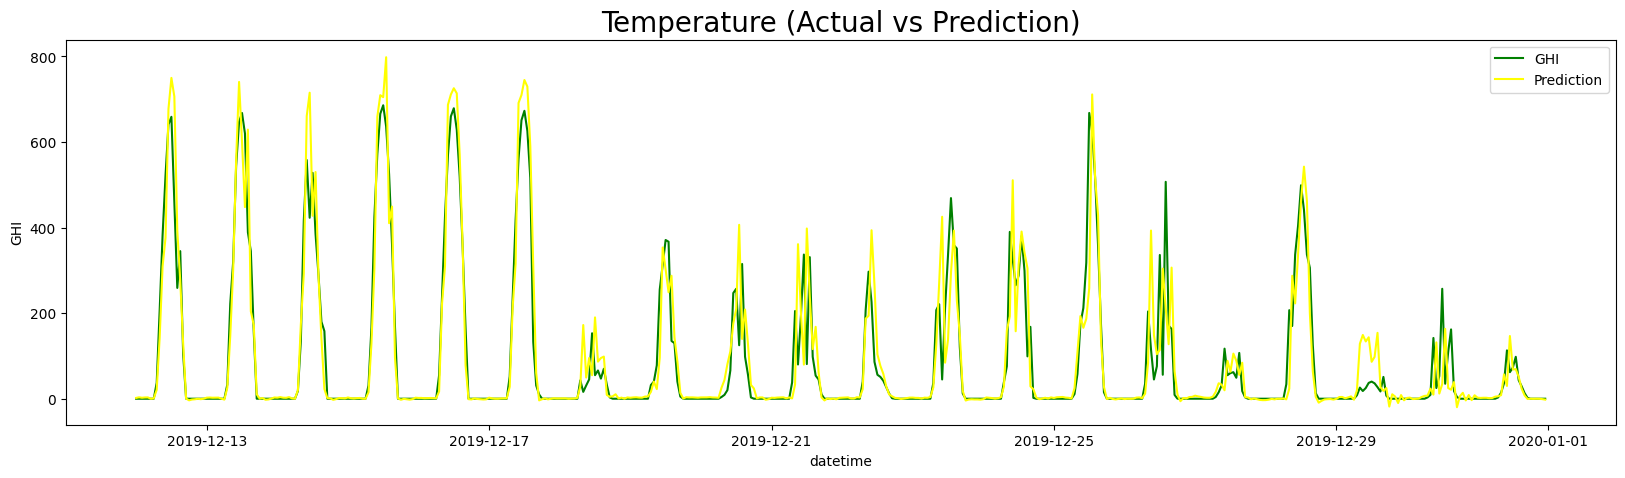

In [43]:
fig = plt.figure(figsize=(20,5)) 
sns.lineplot(data=df_result[-480:], x='datetime', y='GHI', label='GHI', color='green')
sns.lineplot(data=df_result[-480:], x='datetime', y='pred', label='Prediction', color='yellow')
plt.title('Temperature (Actual vs Prediction)', size=20)
plt.legend()
plt.show()